### EDA - EXPLORATORY DATA ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "/home/ander/Escritorio/EchoNet-Dynamic/FileList.csv" # ESTA HARDCODEADO DEBERIAMOS USAR LIBRERIA OS
df = pd.read_csv(path)

clinical_vars = ["EF", "EDV", "ESV"]
video_vars = ["FPS", "NumberOfFrames", "FrameHeight", "FrameWidth"]

In [3]:
print("Shape del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())

print("\nEstadísticos descriptivos:")
print(df.describe())

Shape del dataset: (10030, 9)

Primeras filas:
             FileName         EF         ESV         EDV  FrameHeight  \
0  0X100009310A3BD7FC  78.498406   14.881368   69.210534          112   
1  0X1002E8FBACD08477  59.101988   40.383876   98.742884          112   
2  0X1005D03EED19C65B  62.363798   14.267784   37.909734          112   
3  0X10075961BC11C88E  54.545097   33.143084   72.914210          112   
4  0X10094BA0A028EAC3  24.887742  127.581945  169.855024          112   

   FrameWidth  FPS  NumberOfFrames  Split  
0         112   50             174    VAL  
1         112   50             215  TRAIN  
2         112   50             104  TRAIN  
3         112   55             122  TRAIN  
4         112   52             207    VAL  

Estadísticos descriptivos:
                 EF           ESV           EDV   FrameHeight    FrameWidth  \
count  10030.000000  10030.000000  10030.000000  10030.000000  10030.000000   
mean      55.748248     43.427433     91.324572    112.392423   

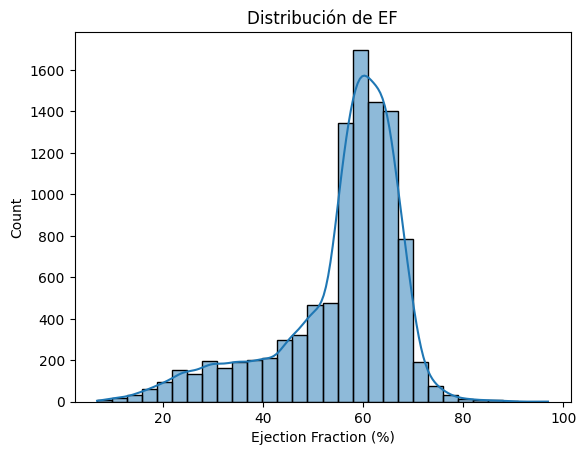

In [4]:
plt.figure()
sns.histplot(df["EF"].dropna(), bins=30, kde=True)
plt.xlabel("Ejection Fraction (%)")
plt.title("Distribución de EF")
plt.show()

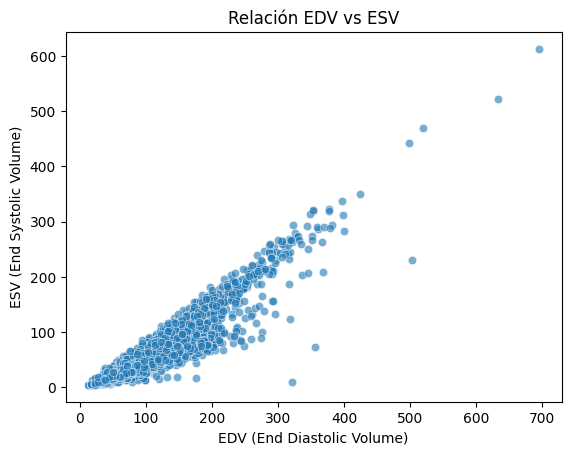

In [5]:
plt.figure()
sns.scatterplot(data=df, x="EDV", y="ESV", alpha=0.6)
plt.xlabel("EDV (End Diastolic Volume)")
plt.ylabel("ESV (End Systolic Volume)")
plt.title("Relación EDV vs ESV")
plt.show()

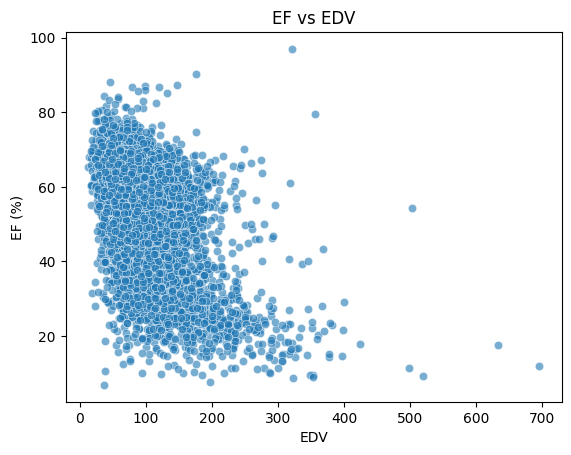

In [6]:
plt.figure()
sns.scatterplot(data=df, x="EDV", y="EF", alpha=0.6)
plt.xlabel("EDV")
plt.ylabel("EF (%)")
plt.title("EF vs EDV")
plt.show()

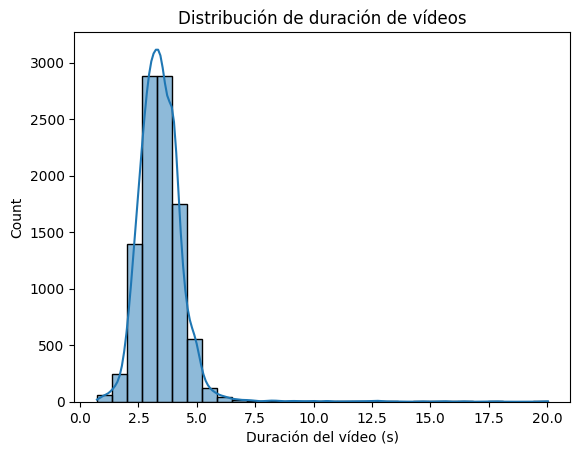

In [7]:
df["Duration_sec"] = df["NumberOfFrames"] / df["FPS"]

plt.figure()
sns.histplot(df["Duration_sec"].dropna(), bins=30, kde=True)
plt.xlabel("Duración del vídeo (s)")
plt.title("Distribución de duración de vídeos")
plt.show()

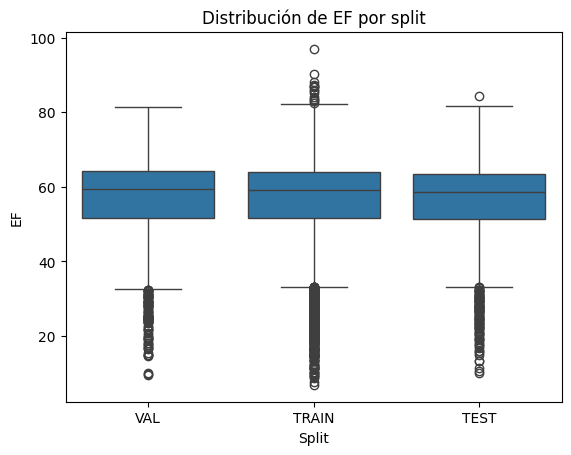

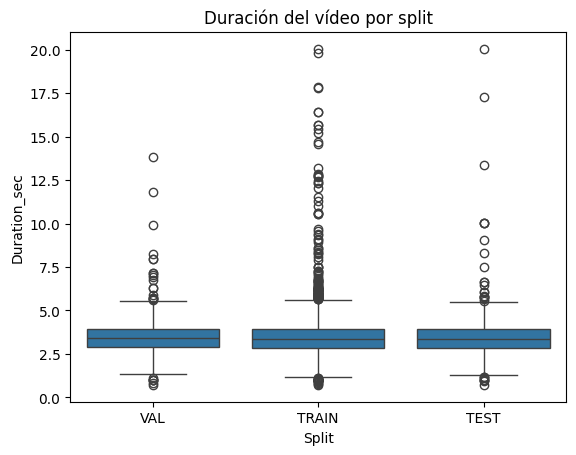

In [8]:
plt.figure()
sns.boxplot(data=df, x="Split", y="EF")
plt.title("Distribución de EF por split")
plt.show()

plt.figure()
sns.boxplot(data=df, x="Split", y="Duration_sec")
plt.title("Duración del vídeo por split")
plt.show()

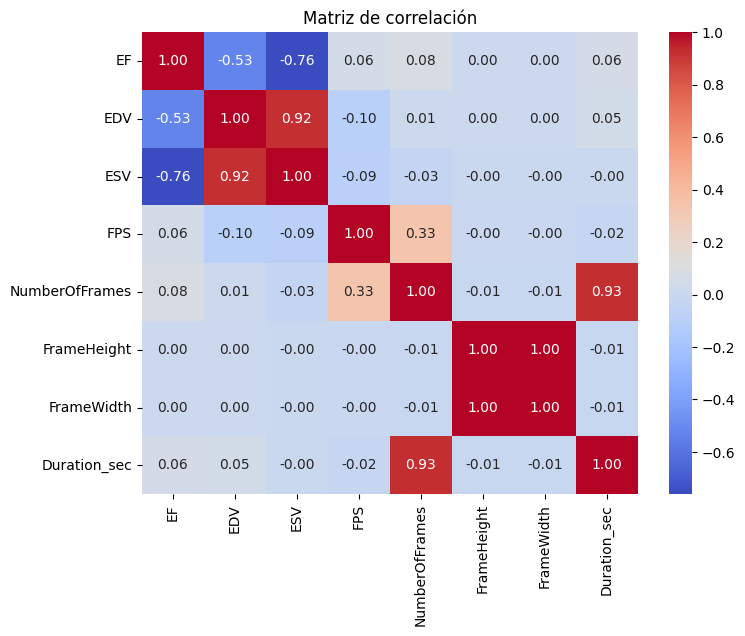

In [9]:
corr_vars = clinical_vars + video_vars + ["Duration_sec"]
corr = df[corr_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

In [10]:
print("\nValores nulos por columna:")
print(df.isna().sum())

print("\nSplits:")
print(df["Split"].value_counts())


Valores nulos por columna:
FileName          0
EF                0
ESV               0
EDV               0
FrameHeight       0
FrameWidth        0
FPS               0
NumberOfFrames    0
Split             0
Duration_sec      0
dtype: int64

Splits:
Split
TRAIN    7465
VAL      1288
TEST     1277
Name: count, dtype: int64
